In [1]:
import os
import math
import matplotlib.pyplot as plt # Thêm
import seaborn as sns # Thêm
from functools import reduce
from operator import add
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
from pyspark.sql import SparkSession, DataFrame
from pyspark.sql.window import Window
from pyspark.sql.types import NumericType
from pyspark.sql import functions as F # Thêm
from pyspark.ml.feature import VectorAssembler, StandardScaler # Thêm
from pyspark.sql.functions import (
    col, when, count,
    to_date, dayofmonth, month, year, date_format, to_timestamp,
    hour as spark_hour, 
    sin, cos, last, first
)
from pyspark.sql import functions as sf
from pyspark.ml.stat import Correlation
import pandas as pd
spark = SparkSession.builder \
    .appName("Weather_Preprocessing_Jupyter") \
    .master("local[*]") \
    .config("spark.driver.memory", "24g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.driver.maxResultSize", "4g") \
    .config("spark.sql.shuffle.partitions", "32") \
    .getOrCreate()


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/24 06:44:58 WARN Utils: Your hostname, admin2025RESNAN, resolves to a loopback address: 127.0.1.1; using 172.27.14.10 instead (on interface eth0)
26/03/24 06:44:58 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/24 06:45:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
def step_1_drop_cols(df: DataFrame) -> DataFrame:
    # 1. Dổi tên cột
    new_columns = [
        'index', 'date', 'hour', 'prcp', 'askq', 'askkmax', 'askkmin', 'bxmt', 
        'tempkk', 'tempds', 'tmax', 'tmin', 'tdsmax', 'tdsmin', 'ttdmax', 'ttdmin', 
        'humi', 'windydirect', 'windygust', 'windyspeed', 'region', 'state', 'station', 
        'station_code', 'latitude', 'longitude', 'elevation'
    ]
    
    if len(df.columns) == len(new_columns):
        df = df.toDF(*new_columns)
    else:
        print(f"CẢNH BÁO: Số lượng cột thực tế ({len(df.columns)}) không khớp ({len(new_columns)}).")
    # 2. Bỏ cột không sài
    cols_to_drop = ['index', 'region', 'state', 'station']
    df = df.drop(*cols_to_drop)
    # 3. Định dạng lại cột hour (2026-03-16 00:00:00 -> 00:00:00)
    df = df.withColumn('hour', date_format(to_timestamp(col('hour')), 'HH:mm:ss'))

    # 4. Xử lý cột date và lọc năm
    if 'date' in df.columns:
        # TẠO CỘT MỚI: Ép kiểu chuỗi về dạng chuẩn DateType và lưu vào 'date_casted'
        df = df.withColumn('date_casted', sf.to_date(sf.col('date')))
        
        # Dùng cột mới 'date_casted' này để bóc tách, cột 'date' gốc vẫn y nguyên
        df = df.withColumn('day', sf.dayofmonth(sf.col('date_casted')))
        df = df.withColumn('month', sf.month(sf.col('date_casted')))
        df = df.withColumn('year', sf.year(sf.col('date_casted')))
        # Vì đã tách xong mục đích chính, mình xóa cột tạm này đi cho gọn, giữ lại date gốc
        df = df.drop('date_casted')
    df = df.filter(col('year') >= 2020)# 15 16 17 18 19 20 21
    return df


def step_2_handle_missing(df):
    numeric_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, NumericType)]
    all_cols = df.columns
    
    # 1. Chuyển các dữ liệu lỗi thành Null
    replace_exprs = [
        when(col(c) == -9999, None).otherwise(col(c)).alias(c) if c in numeric_cols else col(c) 
        for c in all_cols
    ]
    df = df.select(*replace_exprs)

    # 2. Xóa những ngày dữ liệu toàn lỗi
    cols_to_check = [
        'prcp', 'askq', 'askkmax', 'askkmin', 'bxmt', 
        'tempkk', 'tempds', 'tmax', 'tmin', 'tdsmax', 
        'tdsmin', 'ttdmax', 'ttdmin', 'humi', 'windydirect', 
        'windygust', 'windyspeed'
    ]
    
    # Chỉ xét những cột có thật trong df
    actual_cols = [c for c in cols_to_check if c in df.columns]

    if actual_cols and "station_code" in df.columns and "date" in df.columns:
        # Đếm số lượng Not Null của từng cột (Gom nhóm theo TRẠM và NGÀY)
        agg_exprs = [count(col(c)).alias(f"cnt_{c}") for c in actual_cols]
        daily_stats = df.groupBy("station_code", "date").agg(*agg_exprs)

        # Cộng dồn tất cả các biến count lại (Nếu = 0 nghĩa là trọn 24h của ngày đó đều NULL)
        total_valid_expr = reduce(add, [col(f"cnt_{c}") for c in actual_cols])

        # Lọc ra danh sách các NGÀY có ít nhất 1 dòng dữ liệu hợp lệ (> 0)
        valid_days = daily_stats.filter(total_valid_expr > 0).select("station_code", "date")

        # Inner Join: Những ngày toàn NULL sẽ bị loại bỏ sạch sẽ!
        df = df.join(valid_days, on=["station_code", "date"], how="inner")

    # 3. Điền dữ liệu khuyết bằng dữ liệu gần nhất
    # Sắp xếp theo ngày 
    window_ffill = Window.partitionBy("station_code").orderBy("date", "hour") \
                         .rowsBetween(Window.unboundedPreceding, Window.currentRow)
                         
    window_bfill = Window.partitionBy("station_code").orderBy("date", "hour") \
                         .rowsBetween(Window.currentRow, Window.unboundedFollowing)
    
    # Kéo giá trị hợp lệ từ quá khứ xuống
    ffill_exprs = [
        last(col(c), ignorenulls=True).over(window_ffill).alias(c) if c in numeric_cols else col(c) 
        for c in all_cols
    ]
    df = df.select(*ffill_exprs)

    # Đẩy giá trị hợp lệ từ tương lai lên nếu không có giá trị ngày quá khứ
    bfill_exprs = [
        first(col(c), ignorenulls=True).over(window_bfill).alias(c) if c in numeric_cols else col(c) 
        for c in all_cols
    ]
    df = df.select(*bfill_exprs)

    return df

def step_3_rain_label(df: DataFrame) -> DataFrame:
    # Gán nhãn
    if 'prcp' in df.columns:
        df = df.filter(col('prcp').isNotNull()) #! Xóa các cột có giá trị null tại ta không có điền khuyết cho cái cột label

        df = df.withColumn('rain_label', when(col('prcp') > 0, 1).otherwise(0))
    return df

def step_4_datetime_features(df: DataFrame) -> DataFrame:
    # Tính Sin/Cos cho Tháng (Chu kỳ 12 tháng)
    if 'month' in df.columns:
        # Công thức: sin(month * 2 * pi / 12)
        df = df.withColumn('month_sin', sin(col('month') * (2 * math.pi / 12)))
        df = df.withColumn('month_cos', cos(col('month') * (2 * math.pi / 12)))
    return df


def step_5_compute_iqr(
    df: DataFrame,
    columns: list[str] = None,
    relative_error: float = 0.001,
    factor: float = 1.5
) -> DataFrame:
    """
    Xử lý giá trị ngoại lai (Outliers) bằng phương pháp IQR trên TOÀN BỘ dữ liệu.
    Thay thế các giá trị nằm ngoài ngưỡng [Q1 - 1.5*IQR, Q3 + 1.5*IQR] bằng Median (Q2).
    """

    # 1. Tự động xác định danh sách các cột số cần xử lý (Weather metrics)
    if columns is None:
        # Loại trừ các cột định danh, tọa độ và các cột thời gian đã biến đổi
        exclude_cols = {
            'station_code', 'latitude', 'longitude', 'elevation', 
            'rain_label', 'month_sin', 'month_cos',
            'date', 'hour', 'year', 'month', 'day','prcp' # độ lệch chuẩn làm mất thằng này
        }
        columns = [
            f.name for f in df.schema.fields 
            if isinstance(f.dataType, NumericType) and f.name not in exclude_cols
        ]
    
    # 2. Tính toán các phân vị (Quantiles) xấp xỉ
    # relative_error = 0.001 giúp cân bằng độ chính xác khi quét tập dữ liệu lớn
    quantiles_list = df.approxQuantile(columns, [0.25, 0.5, 0.75], relative_error)

    # 3. Duyệt qua kết quả tính toán để xác định ngưỡng cho từng cột
    col_dict = {}
    for i, col_name in enumerate(columns):
        q1, q2, q3 = quantiles_list[i]
        iqr = q3 - q1
        
        lower_bound = q1 - factor * iqr
        upper_bound = q3 + factor * iqr
        
        # Lưu lại ngưỡng và giá trị trung vị (Median) để thay thế
        col_dict[col_name] = (lower_bound, upper_bound, q2)

    # 4. Xây dựng danh sách biểu thức thay thế (Vectorized Transformation)
    replace_exprs = []
    for c in df.columns:
        if c in columns:
            lower, upper, q2 = col_dict[c]
            # Nếu giá trị ngoài khoảng [lower, upper] thì thay bằng Median (q2)
            expr = sf.when((sf.col(c) < lower) | (sf.col(c) > upper), sf.lit(q2)) \
                     .otherwise(sf.col(c)) \
                     .alias(c)
            replace_exprs.append(expr)
        else:
            # Giữ nguyên các cột không thuộc diện xử lý IQR
            replace_exprs.append(sf.col(c))

    # 5. Thực thi biến đổi toàn bộ DataFrame trong 1 lần select duy nhất
    # Việc gom nhóm này giúp Spark tối ưu hóa kế hoạch thực thi (DAG)
    return df.select(*replace_exprs)


def step_6_add_prep(df: DataFrame) -> DataFrame:
    # 1. Tạo Đặc trưng Độ trễ (Lag) cho 17 chỉ số với tiền tố 'pre_'
    lag_columns = [
        'prcp', 'askq', 'askkmax', 'askkmin', 'bxmt', 'tempkk', 'tempds', 
        'tmax', 'tmin', 'tdsmax', 'tdsmin', 'ttdmax', 'ttdmin', 'humi', 
        'windydirect', 'windygust', 'windyspeed'
    ]

    # Sắp xếp trực tiếp bằng cột 'date' và 'hour' sẵn có
    if 'date' in df.columns and 'hour' in df.columns:
        window_spec = Window.partitionBy("station_code").orderBy("date", "hour")
        
        for col_name in lag_columns:
            if col_name in df.columns:
                pre_col_name = f"pre_{col_name}"  # Tạo tên cột mới có chữ pre_
                
                # Kéo dữ liệu của giờ trước
                df = df.withColumn(pre_col_name, sf.lag(col_name, 1).over(window_spec))
                
                # Lấp giá trị Null của dòng đầu tiên bằng chính giá trị dòng đó
                df = df.withColumn(pre_col_name, sf.coalesce(sf.col(pre_col_name), sf.col(col_name)))

    # 2. Dọn dẹp các cột thời gian gốc (Tránh học vẹt)
    cols_to_drop_final = ['hour', 'year', 'day', 'month']
    existing_cols = [c for c in cols_to_drop_final if c in df.columns]
    
    df = df.drop(*existing_cols)

    return df


def step_7_correlation(df_processed_1):
    total_rows = df_processed_1.count()
    numeric_cols = [
        f.name for f in df_processed_1.schema.fields 
        if isinstance(f.dataType, NumericType) and f.name != 'rain_label'
    ]
    # Tính statistics một lần duy nhất
    stats_exprs = []
    for c in numeric_cols:
        stats_exprs.extend([
            F.count(F.when(F.col(c).isNull(), 1)).alias(f"{c}_null"),
            F.sum(F.when(F.col(c) == -9999, 1)).alias(f"{c}_neg9999"),
            F.sum(F.when(F.col(c) == 0, 1)).alias(f"{c}_zero"),
            F.stddev_pop(c).alias(f"{c}_std"),
            F.count(c).alias(f"{c}_count")
        ])
        
    quality_stats = df_processed_1.select(*stats_exprs).collect()[0].asDict()
    
    # Xác định cột lỗi và cột hợp lệ
    bad_cols = []
    valid_features = []
    print("Đang đánh giá chất lượng các cột...")
    for c in numeric_cols:
        null_cnt     = quality_stats.get(f"{c}_null", 0) or 0
        neg9999_cnt  = quality_stats.get(f"{c}_neg9999", 0) or 0
        zero_cnt     = quality_stats.get(f"{c}_zero", 0) or 0
        std_val      = quality_stats.get(f"{c}_std")
        
        null_pct     = null_cnt / total_rows
        neg9999_pct  = neg9999_cnt / total_rows
        
        # Ngưỡng loại bỏ
        if (null_pct + neg9999_pct > 0.30) or (std_val is None or std_val < 1e-6):
            bad_cols.append(c)
        else:
            valid_features.append(c)

    print(f"Giữ lại {len(valid_features)} cột hợp lệ | Loại bỏ {len(bad_cols)} cột kém chất lượng\n")

    # 1. Tính toán & Vẽ Heatmap trên 100% dữ liệu
    cols_for_corr = valid_features + ['rain_label']
    assembler = VectorAssembler(
        inputCols=cols_for_corr, 
        outputCol="features_vec", 
        handleInvalid="skip"
    )

    df_vector = assembler.transform(df_processed_1).select("features_vec")
    
    print("Đang tính toán ma trận tương quan (Heatmap)...")
    corr_spark_result = Correlation.corr(df_vector, "features_vec", "pearson").head()[0]
    corr_matrix_np = corr_spark_result.toArray()
    corr_matrix_pd = pd.DataFrame(corr_matrix_np, index=cols_for_corr, columns=cols_for_corr)

    plt.figure(figsize=(20, 20))
    sns.heatmap(corr_matrix_pd, 
                annot=True, 
                cmap='coolwarm', 
                fmt='.2f', 
                linewidths=0.5,
                annot_kws={"size": 8})

    plt.title('Ma Trận Tương Quan Pearson (Trên 100% Dữ Liệu)', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout() # Đảm bảo chữ không bị cắt viền
    
    image_name = "heatmap_tuongquan.png"
    plt.savefig(image_name, dpi=300, bbox_inches='tight')
    print(f"✅ Đã lưu biểu đồ Heatmap thành ảnh chất lượng cao: '{image_name}'")    
    plt.show()

    # 2. Tính Correlation với rain_label 
    print("\nTính Correlation với biến mục tiêu...")
    corr_exprs = [F.corr(F.col(c), F.col("rain_label")).alias(c) for c in valid_features]
    corr_row = df_processed_1.select(*corr_exprs).collect()[0].asDict()
    # Sắp xếp toàn bộ biến theo độ lớn tương quan (trị tuyệt đối)
    sorted_features = sorted(
        [(f, abs(v)) for f, v in corr_row.items() if v is not None],
        key=lambda x: x[1], 
        reverse=True
    )
    # ==========================================
    # 3. Lưu toàn bộ độ tương quan vào file tuongquan.txt
    # ==========================================
    file_name = "tuongquan.txt"
    print(f"\nĐang ghi toàn bộ chỉ số tương quan vào file '{file_name}'...")
    
    # Mở file với chế độ 'w' (write - ghi đè) và encoding utf-8 để hỗ trợ tiếng Việt
    with open(file_name, "w", encoding="utf-8") as f:
        f.write("BẢNG XẾP HẠNG ĐỘ TƯƠNG QUAN PEARSON VỚI RAIN_LABEL\n")
        f.write("=" * 60 + "\n")
        f.write(f"{'Hạng':<6} | {'Tên biến (Feature)':<25} | {'Độ tương quan (Correlation)':<20}\n")
        f.write("-" * 60 + "\n")
        
        # Duyệt qua toàn bộ danh sách để ghi từng dòng
        for rank, (feat, score) in enumerate(sorted_features, 1):
            f.write(f"{rank:<6} | {feat:<25} | {score:.6f}\n")
            
        f.write("=" * 60 + "\n")
        f.write(f"Tổng số biến hợp lệ: {len(sorted_features)}\n")

    # 1. Danh sách 11 biến (features) tinh túy nhất mà bạn đã chốt
    final_features = [
        'pre_prcp', 
        'ttdmax', 
        'tempkk', 
        'tempds', 
        'bxmt', 
        'month_sin', 
        'windydirect', 
        'pre_windydirect', 
        'askkmax', 
        'windyspeed', 
        'month_cos'
    ]
    columns_to_keep = ['station_code', 'date'] + final_features + ['rain_label']
    existing_cols_to_keep = [c for c in columns_to_keep if c in df_processed_1.columns]
    df_processed_1 = df_processed_1.select(*existing_cols_to_keep)
    # Danh sách các cột cần nắn lại phân phối
    cols_to_log = ['pre_prcp', 'windyspeed', 'bxmt']

    for c in cols_to_log:
        if c in df_processed_1.columns:
            # log1p giúp xử lý các giá trị bằng 0 an toàn
            df_processed_1 = df_processed_1.withColumn(c, F.log1p(F.col(c)))
    return df_processed_1



def step_8_preparation(df_processed_1):
    # 1. Danh sách 11 biến tinh túy nhất đã chốt
    selected_features = [
        'pre_prcp', 'ttdmax', 'tempkk', 'tempds', 'bxmt', 
        'month_sin', 'windydirect', 'pre_windydirect', 
        'askkmax', 'windyspeed', 'month_cos'
    ]
    # 2. Vector Assembler: Đóng gói 11 cột thành 1 cột vector duy nhất
    # THÊM THAM SỐ: handleInvalid="skip"
    assembler = VectorAssembler(
        inputCols=selected_features, 
        outputCol="features_raw",
        handleInvalid="skip" # <--- THÊM DÒNG NÀY: Thấy null là tự bỏ qua dòng đó
    )
    # 3. Chỉ giữ lại vector đặc trưng và nhãn rain_label
    df_model = assembler.transform(df_processed_1).select("features_raw", "rain_label")
    train_df, test_df = df_model.randomSplit([0.7, 0.3], seed=42)
    # 4. Standard Scaler: Chuẩn hóa về thang đo chuẩn (Mean=0, Std=1)
    scaler = StandardScaler(inputCol="features_raw", 
                           outputCol="features", 
                           withStd=True, 
                           withMean=True)
    # 5. Học thông số chuẩn hóa từ tập Train
    scaler_model = scaler.fit(train_df)
    train_scaled = scaler_model.transform(train_df).select("features", "rain_label")
    test_scaled  = scaler_model.transform(test_df).select("features", "rain_label")    
    train_path = "train_data_folder.parquet"
    test_path = "test_data_folder.parquet"
    train_scaled.write.mode("overwrite").parquet(train_path)
    test_scaled.write.mode("overwrite").parquet(test_path)
    train_scaled.cache()
    test_scaled.cache()
    print(f"📊 Kích thước Train: {train_scaled.count():,} dòng")
    print(f"📊 Kích thước Test : {test_scaled.count():,} dòng")
    return train_scaled, test_scaled



Đang đọc dữ liệu từ 'data.parquet'...



--- BẮT ĐẦU LUỒNG TIỀN XỬ LÝ BƯỚC 1 TỚI 8 ---
-> Chạy Bước 1...
-> Chạy Bước 2...


26/03/24 06:45:14 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


-> Chạy Bước 3...
-> Chạy Bước 4...
-> Chạy Bước 5...


-> Chạy Bước 6...
-> Chạy Bước 7...


Đang đánh giá chất lượng các cột...
Giữ lại 39 cột hợp lệ | Loại bỏ 0 cột kém chất lượng

Đang tính toán ma trận tương quan (Heatmap)...


✅ Đã lưu biểu đồ Heatmap thành ảnh chất lượng cao: 'heatmap_tuongquan.png'


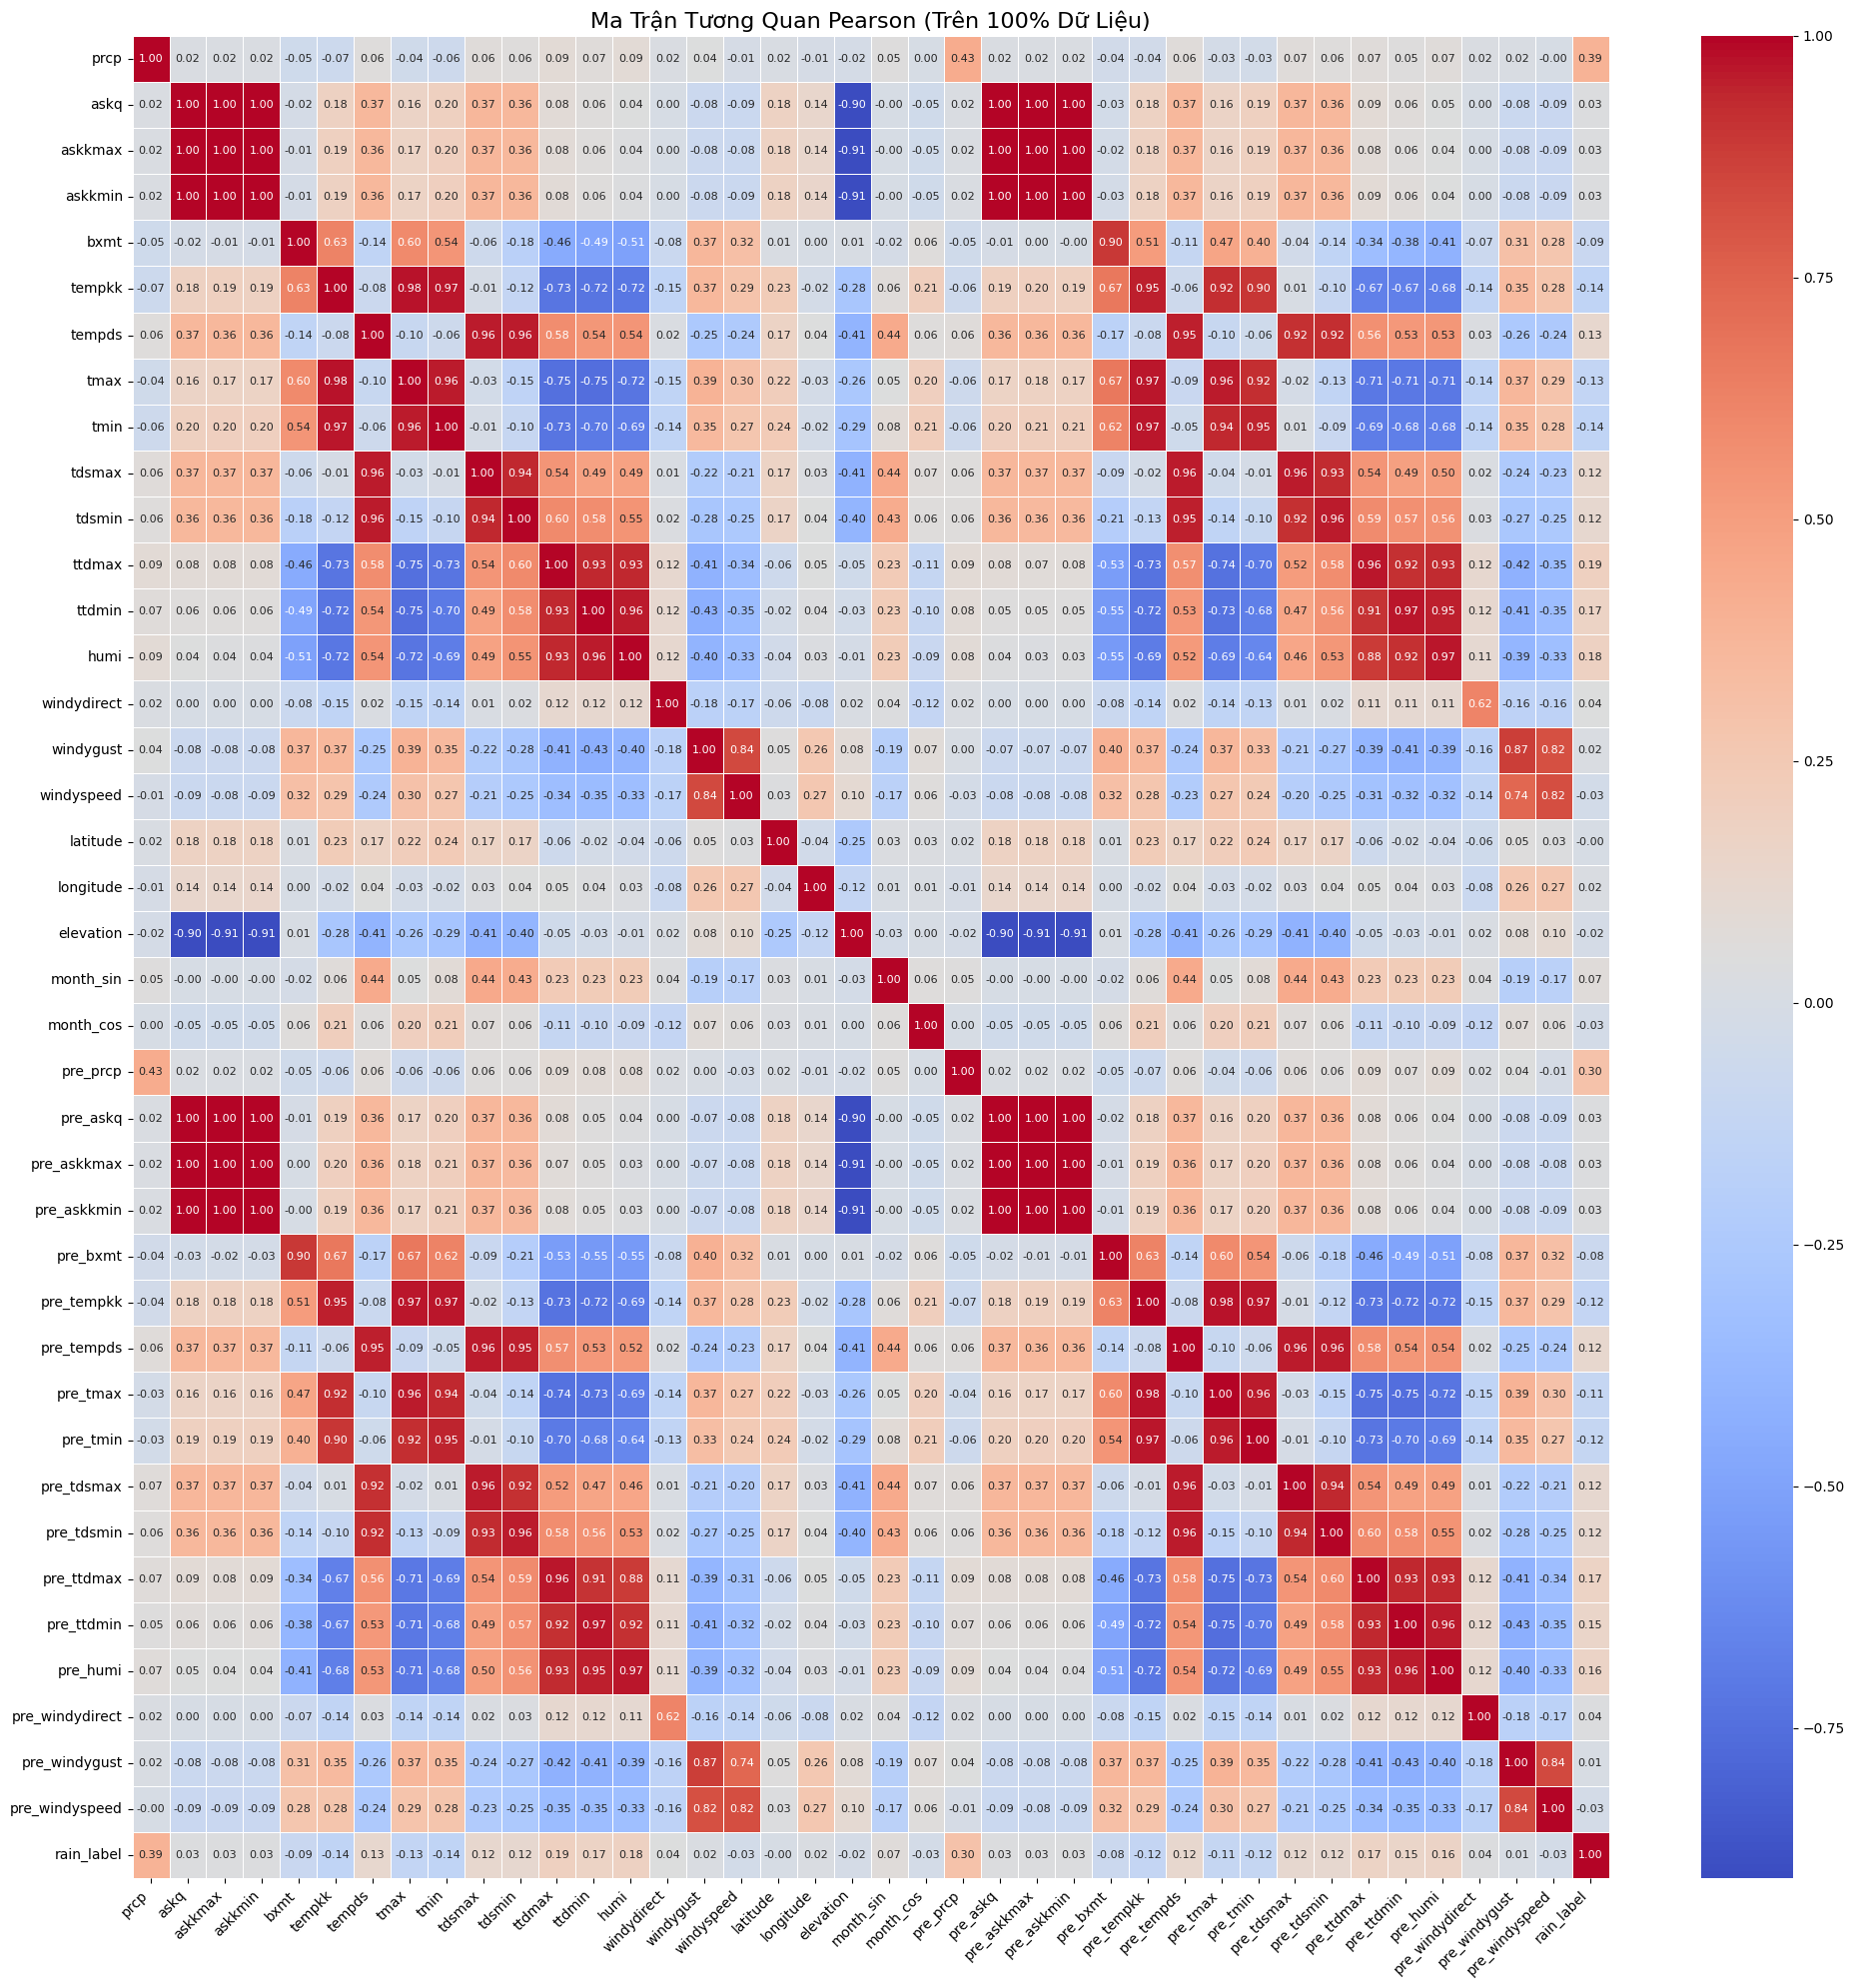


Tính Correlation với biến mục tiêu...



Đang ghi toàn bộ chỉ số tương quan vào file 'tuongquan.txt'...


📊 Kích thước Train: 861,001 dòng


📊 Kích thước Test : 369,095 dòng


In [3]:
def run_preprocessing_pipeline(df: DataFrame) -> DataFrame:
    print("-> Chạy Bước 1...")
    df1 = step_1_drop_cols(df)

    print("-> Chạy Bước 2...")
    df2 = step_2_handle_missing(df1)
    
    df2.cache()

    print("-> Chạy Bước 3...")
    df3 = step_3_rain_label(df2)

    print("-> Chạy Bước 4...")
    df4 = step_4_datetime_features(df3)

    print("-> Chạy Bước 5...")
    df5 = step_5_compute_iqr(df4)

    print("-> Chạy Bước 6...")
    df6 = step_6_add_prep(df5)

    print("-> Chạy Bước 7...")
    df7 = step_7_correlation(df6) 

    df2.unpersist()

    return df7

input_file = 'data.parquet'
print(f"Đang đọc dữ liệu từ '{input_file}'...")
df = spark.read.parquet(input_file)
print("\n--- BẮT ĐẦU LUỒNG TIỀN XỬ LÝ BƯỚC 1 TỚI 8 ---")
df_processed_1 = run_preprocessing_pipeline(df) # TIỀN XỬ LÝ 1-7
train_data, testdata = step_8_preparation(df_processed_1)


In [4]:
output_parquet_path = "data_processed_final.parquet"

print(f"Đang xuất dữ liệu ra định dạng Parquet tại: '{output_parquet_path}'...")

df_processed_1.write.mode("overwrite").parquet(output_parquet_path)

print("Đã xuất file Parquet thành công! cho tới bước 7")

Đang xuất dữ liệu ra định dạng Parquet tại: 'data_processed_final.parquet'...


Đã xuất file Parquet thành công! cho tới bước 7
